In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
DATA_PATH = r"C:\Users\vinay\Downloads\SkillAudit-Airbnb-Week1\WEEK-1\airbnb_nyc_2019_dataset_cleaned.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["last_review"])

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1001, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,1900-01-01,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Descriptive statistics

**Question:** What do the main numerical variables look like?

Mean and median are both included because Airbnb prices and review counts can be skewed.


In [18]:
# Descriptive statistics for numeric columns
print("Descriptive statistics:\n")
print(df.describe())

print("\nMedian values:\n")
print(df.median(numeric_only=True))

Descriptive statistics:

                  id       host_id     latitude    longitude        price  \
count    1001.000000  1.001000e+03  1001.000000  1001.000000  1001.000000   
mean   175385.307692  7.426748e+05    40.728185   -73.963397   158.211788   
min      2539.000000  2.787000e+03    40.581470   -74.165340    20.000000   
25%     62461.000000  2.022490e+05    40.687680   -73.984520    85.000000   
50%    177421.000000  5.510550e+05    40.722120   -73.960930   127.000000   
75%    270681.000000  1.240820e+06    40.757440   -73.948400   195.000000   
max    404923.000000  1.060985e+07    40.897470   -73.761330  3000.000000   
std    116411.536270  7.760416e+05     0.051575     0.033417   151.971909   

       minimum_nights  number_of_reviews                 last_review  \
count     1001.000000        1001.000000                        1001   
mean         9.130869          80.027972  2013-10-09 19:13:43.576423   
min          1.000000           0.000000         1900-01-01 00:00

## Visualization 1 — Price distribution

**Question:** How are Airbnb listing prices distributed?

The chart is limited to prices up to $500 only for readability. No records are deleted from the dataset.


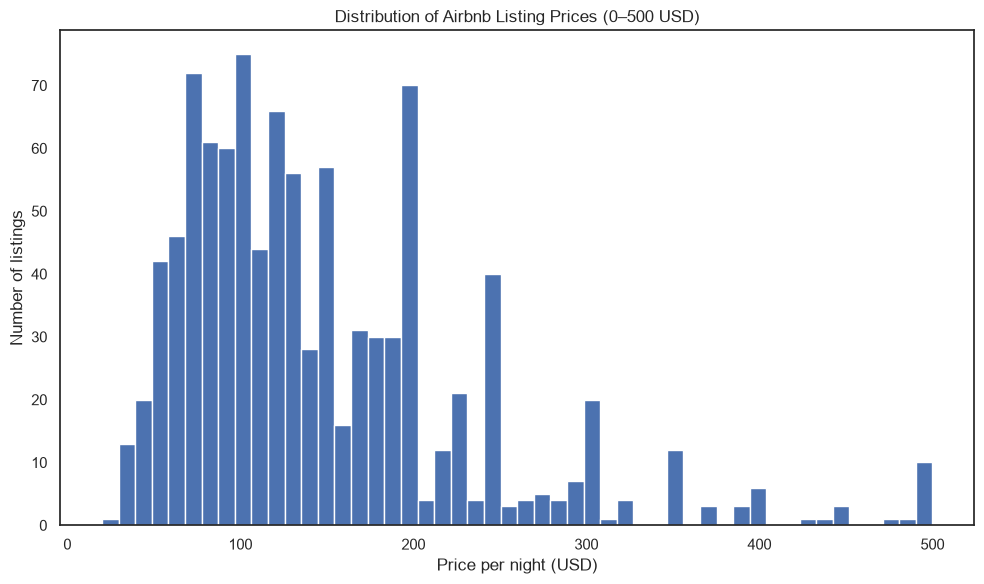

In [35]:
price_for_chart = df.loc[
    (df["price"] >= 0) & (df["price"] <= 500), "price"
]

plt.figure(figsize=(10, 6))
plt.hist(price_for_chart, bins=50)
plt.title("Distribution of Airbnb Listing Prices (0–500 USD)")
plt.xlabel("Price per night (USD)")
plt.ylabel("Number of listings")
plt.tight_layout()
plt.show()

## Visualization 2 — Average price by room type

**Question:** How does average nightly price differ across room types?


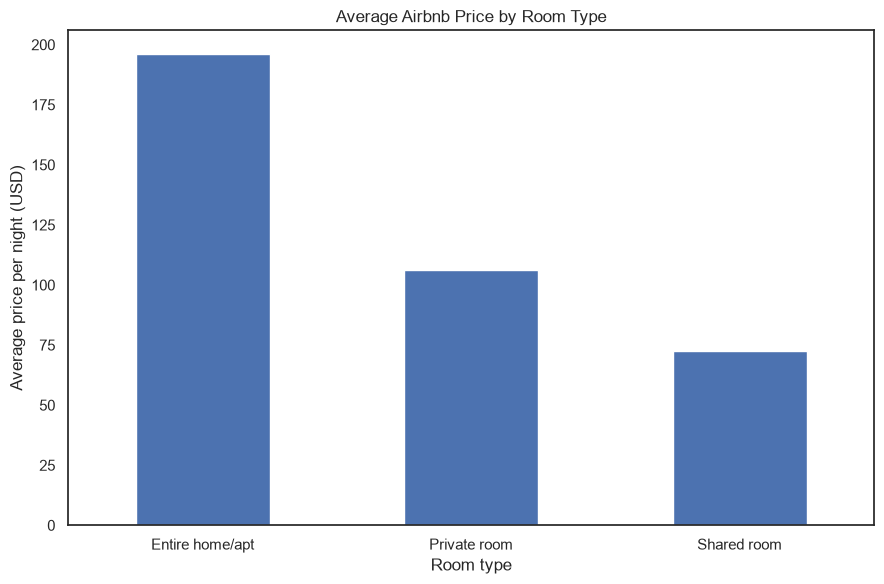

In [34]:
avg_price_room = (
    df.groupby("room_type", observed=True)["price"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))
avg_price_room.plot(kind="bar")
plt.title("Average Airbnb Price by Room Type")
plt.xlabel("Room type")
plt.ylabel("Average price per night (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Visualization 3 — Average price by neighbourhood group

**Question:** How does average listing price vary across NYC neighbourhood groups?


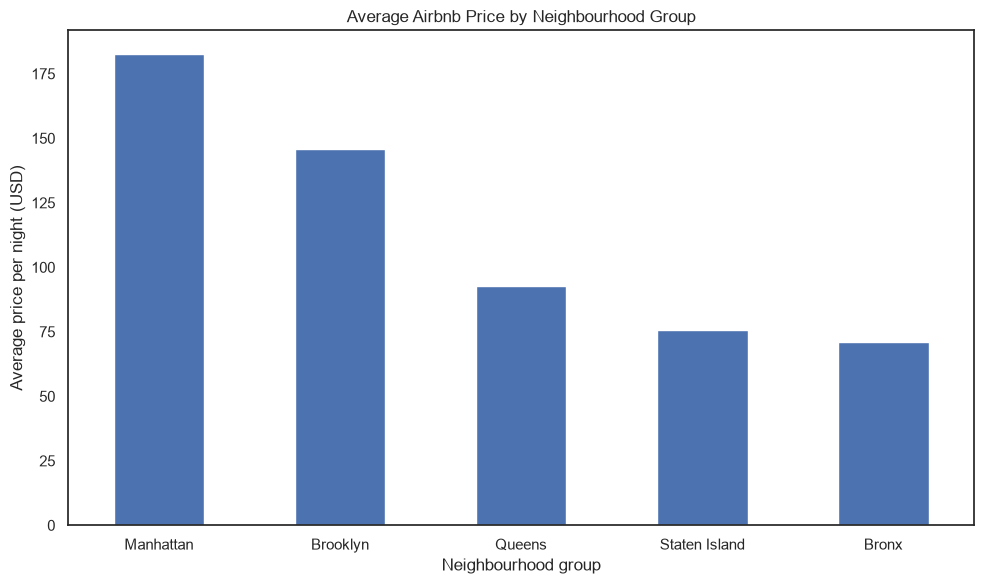

In [33]:
avg_price_neighbourhood = (
    df.groupby("neighbourhood_group", observed=True)["price"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
avg_price_neighbourhood.plot(kind="bar")
plt.title("Average Airbnb Price by Neighbourhood Group")
plt.xlabel("Neighbourhood group")
plt.ylabel("Average price per night (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Visualization 4 — Airbnb Price Distribution by Room Type

**Question:** How does Airbnb price vary across different room types?


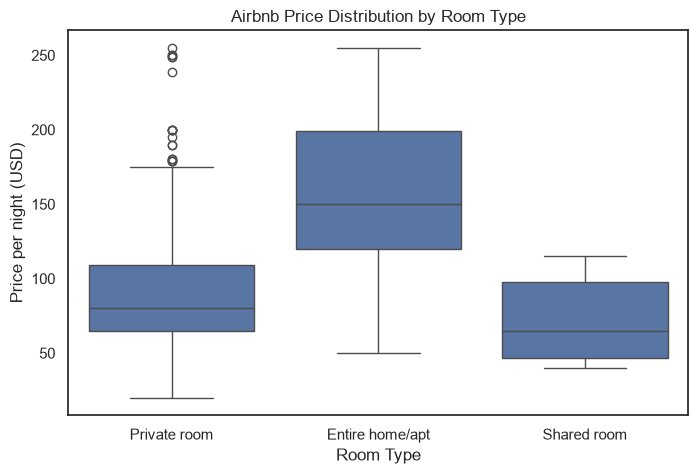

In [32]:
price_90 = df["price"].quantile(0.90)
plot_df = df[df["price"] <= price_90]

plt.figure(figsize=(8, 5))

sns.boxplot(x="room_type", y="price", data=plot_df)

plt.title("Airbnb Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price per night (USD)")
plt.grid(False)
plt.show()

## Visualization 5 — Price vs number of reviews

**Question:** Is there an obvious linear relationship between price and number of reviews?

Only prices up to $500 are shown for readability; this is a visualization filter, not data deletion.


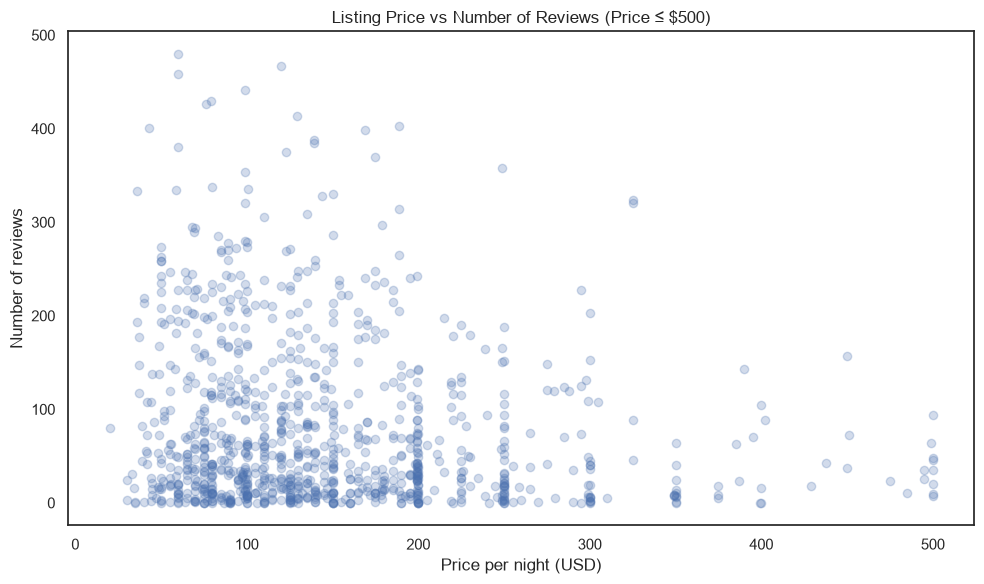

In [36]:
scatter_df = df.loc[
    (df["price"] > 0) & (df["price"] <= 500)
].copy()

plt.figure(figsize=(10, 6))
plt.scatter(scatter_df["price"], scatter_df["number_of_reviews"], alpha=0.25)
plt.title("Listing Price vs Number of Reviews (Price ≤ $500)")
plt.xlabel("Price per night (USD)")
plt.ylabel("Number of reviews")
plt.tight_layout()
plt.show()

corr = scatter_df["price"].corr(scatter_df["number_of_reviews"])

## Visualization 6 — Correlation heatmap

**Question:** Which numerical variables have stronger or weaker linear relationships?


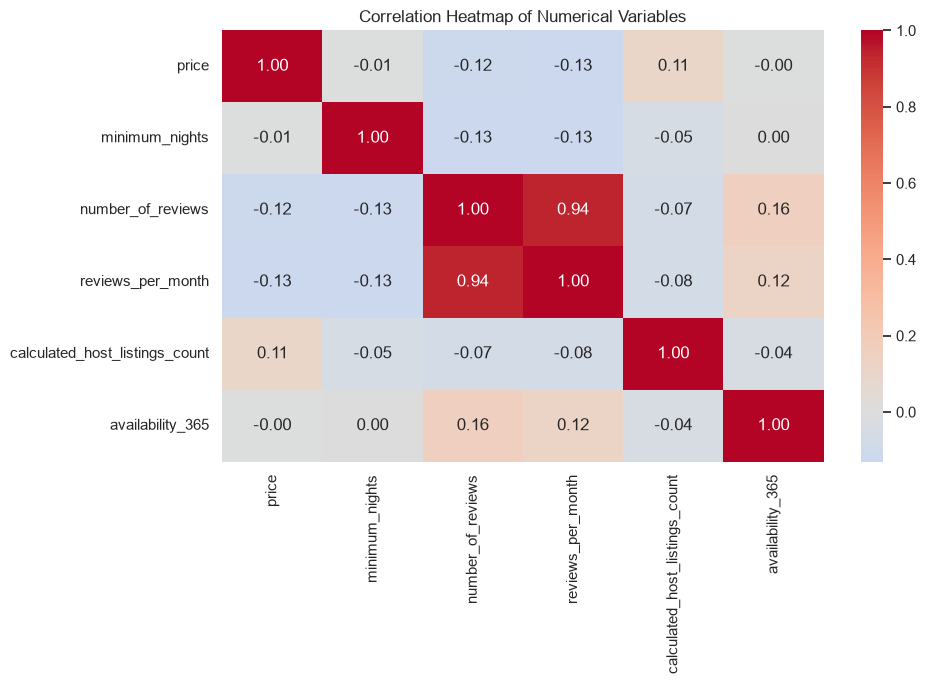

In [37]:
corr_cols = [
    "price", "minimum_nights", "number_of_reviews",
    "reviews_per_month", "calculated_host_listings_count",
    "availability_365"
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

## Export EDA summary

The reference Week 2 repository uses `EDA_summary.csv`, so this project creates the same type of output.


In [40]:
# Create EDA summary CSV
summary = df.describe()
summary.to_csv("EDA_summary.csv")